# 📐 Modelagem Linear para Aprendizado de Máquina

**Prof. Saulo Joel**

---

### 📋 Ementa

> *Construir e interpretar modelos lineares, aplicando-os em problemas reais usando Python e bibliotecas como **scikit-learn** e **TensorFlow**. Estudaremos também técnicas de **regularização** e **seleção de variáveis**, essenciais para a criação de modelos robustos e eficientes.*

### 🎯 Objetivos de Aprendizagem

Ao final desta aula, o aluno será capaz de:

1. **Construir** modelos de regressão linear (simples e múltipla) e regressão logística
2. **Interpretar** os coeficientes e métricas dos modelos lineares
3. **Aplicar técnicas de regularização** (Ridge $L_2$, Lasso $L_1$, ElasticNet) para controlar overfitting
4. **Realizar seleção de variáveis** utilizando Lasso e RFE (Recursive Feature Elimination)
5. **Implementar** modelos lineares tanto com **scikit-learn** quanto com **TensorFlow/Keras**
6. **Avaliar e comparar** modelos usando métricas adequadas e validação cruzada

### 📚 Conteúdo

| Seção | Modelo / Técnica | Tipo | Biblioteca |
|-------|------------------|------|------------|
| 4 | Regressão Linear Simples | Regressão | scikit-learn |
| 5 | Regressão Linear Múltipla | Regressão | scikit-learn |
| 7 | Ridge Regression | Regularização $L_2$ | scikit-learn |
| 8 | Lasso Regression | Regularização $L_1$ | scikit-learn |
| 9 | ElasticNet | Regularização $L_1 + L_2$ | scikit-learn |
| 10 | Seleção de Variáveis | Feature Selection | scikit-learn |
| 11 | Regressão Logística | Classificação | scikit-learn |
| 13 | Regressão Linear com TensorFlow | Regressão | TensorFlow/Keras |

**Dataset utilizado:**
- 🚗 **Auto MPG** — dataset real clássico de ML com atributos de automóveis (cilindros, potência, peso, aceleração, etc.). Usado tanto para **regressão** (prever mpg) quanto para **classificação** binária (Econômico vs Gastão, baseado na mediana do consumo)

## 1. Instalação e Importação das Bibliotecas

Antes de começar, vamos garantir que todas as dependências estejam instaladas no ambiente.

> ⚠️ **Execute a célula abaixo apenas na primeira vez** ou caso alguma biblioteca esteja faltando.

In [1]:
# Instalação das dependências necessárias
%pip install numpy pandas matplotlib seaborn scikit-learn scipy --quiet
%pip install protobuf==5.29.4 --quiet
%pip install tensorflow --quiet

# Correção para conflito protobuf/TensorFlow em ambientes Anaconda
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print("✅ Dependências instaladas!")
print("⚠️  Se for a primeira instalação do TensorFlow, reinicie o kernel antes de continuar.")

Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.52.2 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
✅ Dependências instaladas!
⚠️  Se for a primeira instalação do TensorFlow, reinicie o kernel antes de continuar.


In [2]:
# Bibliotecas fundamentais e importação de módulos específicos
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn — Datasets
from sklearn.datasets import fetch_openml

# Scikit-Learn — Pré-processamento e divisão dos dados
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Scikit-Learn — Modelos Lineares
from sklearn.linear_model import (
    LinearRegression,
    Ridge, RidgeCV,
    Lasso, LassoCV,
    ElasticNet, ElasticNetCV,
    LogisticRegression,
)

# Scikit-Learn — Métricas
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

# Scikit-Learn — Seleção de Variáveis
from sklearn.feature_selection import RFE, SelectFromModel

# TensorFlow / Keras (conforme ementa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas importadas com sucesso!")
print(f"   scikit-learn: {__import__('sklearn').__version__}")
print(f"   TensorFlow:   {tf.__version__}")

✅ Todas as bibliotecas importadas com sucesso!
   scikit-learn: 1.8.0
   TensorFlow:   2.21.0


## 2. Carregamento e Exploração dos Datasets

### 2.1 Auto MPG (Regressão)

O **Auto MPG** é um dataset clássico de Machine Learning, originalmente do repositório UCI. Contém dados de **398 automóveis** com atributos como cilindros, potência, peso, aceleração e origem, sendo o objetivo prever o **consumo em milhas por galão (mpg)**.

O dataset possui variáveis de **tipos mistos**:
- **Numéricas:** displacement, horsepower, weight, acceleration
- **Categóricas:** cylinders, model (ano do modelo), origin (país de origem)

Utilizaremos **One-Hot Encoding** (`pd.get_dummies`) para converter as variáveis categóricas em numéricas, o que expandirá o número de features. Isso é ideal para demonstrar o poder da **regularização** e **seleção de variáveis** — o Lasso, por exemplo, deve ser capaz de identificar e zerar as features menos relevantes.

> 💡 **Vantagem didática:** por ser um dataset **real**, os resultados são mais representativos do que encontramos na prática de Machine Learning.

In [3]:
# Carregar o dataset Auto MPG do OpenML
auto = fetch_openml(data_id=196, as_frame=True)
df_reg = auto.frame.copy()

# O OpenML nomeia a variável-alvo como 'class'; renomear para 'mpg'
df_reg = df_reg.rename(columns={'class': 'mpg'})

# Remover a coluna 'car name' (identificador textual, não preditivo)
if 'car name' in df_reg.columns:
    df_reg = df_reg.drop(columns=['car name'])

# Tratar valores ausentes (horsepower possui NaN)
print(f"Valores ausentes antes da limpeza:\n{df_reg.isnull().sum()[df_reg.isnull().sum() > 0]}\n")
df_reg = df_reg.dropna(subset=['horsepower'])

# Identificar colunas categóricas e numéricas
cat_cols = ['cylinders', 'model', 'origin']
num_cols = ['displacement', 'horsepower', 'weight', 'acceleration']

# Converter categóricas para string (garantir tratamento correto)
for col in cat_cols:
    df_reg[col] = df_reg[col].astype(str)

# Aplicar One-Hot Encoding nas categóricas
df_reg = pd.get_dummies(df_reg, columns=cat_cols, drop_first=True, dtype=float)

# Definir feature_names (tudo exceto 'mpg')
feature_names = [c for c in df_reg.columns if c != 'mpg']

print("🚗 Auto MPG Dataset")
print(f"   Amostras: {df_reg.shape[0]} | Features: {len(feature_names)}")
print(f"   Variáveis numéricas originais: {num_cols}")
print(f"   Variáveis categóricas (one-hot encoded): {cat_cols}")
print(f"   Variável-alvo: mpg (milhas por galão)\n")
df_reg.head()

Valores ausentes antes da limpeza:
horsepower    6
dtype: int64

🚗 Auto MPG Dataset
   Amostras: 392 | Features: 22
   Variáveis numéricas originais: ['displacement', 'horsepower', 'weight', 'acceleration']
   Variáveis categóricas (one-hot encoded): ['cylinders', 'model', 'origin']
   Variável-alvo: mpg (milhas por galão)



,displacement,horsepower,weight,acceleration,mpg,cylinders_4,cylinders_5,cylinders_6,cylinders_8,model_71,...,model_75,model_76,model_77,model_78,model_79,model_80,model_81,model_82,origin_2,origin_3
0,307.0,130.0,3504,12.0,18.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,350.0,165.0,3693,11.5,15.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,318.0,150.0,3436,11.0,18.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,304.0,150.0,3433,12.0,16.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,302.0,140.0,3449,10.5,17.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Informações e estatísticas descritivas
print("Informações do dataset:")
print(df_reg.info())
print("\n" + "="*60)
print("\nEstatísticas descritivas:")
df_reg.describe()

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  392 non-null    float64
 1   horsepower    392 non-null    float64
 2   weight        392 non-null    int64  
 3   acceleration  392 non-null    float64
 4   mpg           392 non-null    float64
 5   cylinders_4   392 non-null    float64
 6   cylinders_5   392 non-null    float64
 7   cylinders_6   392 non-null    float64
 8   cylinders_8   392 non-null    float64
 9   model_71      392 non-null    float64
 10  model_72      392 non-null    float64
 11  model_73      392 non-null    float64
 12  model_74      392 non-null    float64
 13  model_75      392 non-null    float64
 14  model_76      392 non-null    float64
 15  model_77      392 non-null    float64
 16  model_78      392 non-null    float64
 17  model_79      392 non-null    float64
 18  model_80   

,displacement,horsepower,weight,acceleration,mpg,cylinders_4,cylinders_5,cylinders_6,cylinders_8,model_71,...,model_75,model_76,model_77,model_78,model_79,model_80,model_81,model_82,origin_2,origin_3
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,...,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,194.411990,104.469388,2977.584184,15.541327,23.445918,0.507653,0.007653,0.211735,0.262755,0.068878,...,0.076531,0.086735,0.071429,0.091837,0.073980,0.068878,0.071429,0.076531,0.173469,0.201531
std,104.644004,38.491160,849.402560,2.758864,7.805007,0.500580,0.087258,0.409060,0.440693,0.253569,...,0.266185,0.281806,0.257869,0.289164,0.262072,0.253569,0.257869,0.266185,0.379136,0.401656
min,68.000000,46.000000,1613.000000,8.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,105.000000,75.000000,2225.250000,13.775000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,151.000000,93.500000,2803.500000,15.500000,22.750000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,275.750000,126.000000,3614.750000,17.025000,29.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,455.000000,230.000000,5140.000000,24.800000,46.600000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


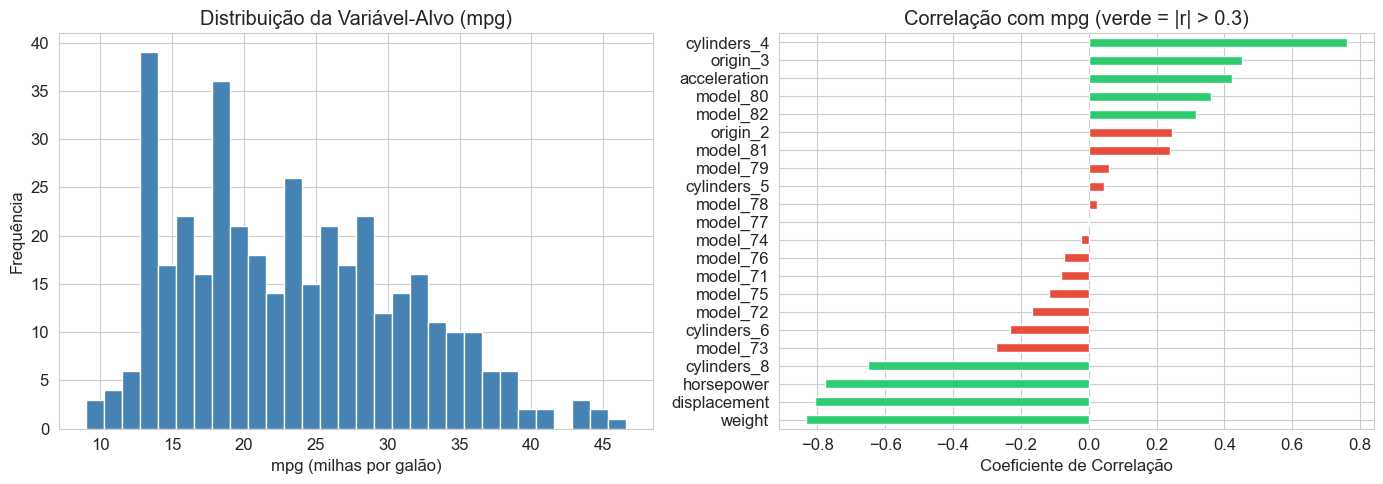


🎯 Feature com maior correlação absoluta: weight (r = -0.8322)


In [5]:
# Distribuição da variável-alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_reg['mpg'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição da Variável-Alvo (mpg)')
axes[0].set_xlabel('mpg (milhas por galão)')
axes[0].set_ylabel('Frequência')

# Correlação entre features numéricas e a variável-alvo
corr = df_reg.corr(numeric_only=True)['mpg'].drop('mpg').sort_values()
colors = ['#2ecc71' if abs(c) > 0.3 else '#e74c3c' for c in corr]
corr.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Correlação com mpg (verde = |r| > 0.3)')
axes[1].set_xlabel('Coeficiente de Correlação')

plt.tight_layout()
plt.show()

# Identificar a feature com maior correlação (para regressão simples)
best_feature = corr.abs().idxmax()
print(f"\n🎯 Feature com maior correlação absoluta: {best_feature} (r = {corr[best_feature]:.4f})")

### 2.2 Auto MPG — Classificação Binária

Para demonstrar a **Regressão Logística**, vamos criar uma tarefa de **classificação binária** a partir do mesmo dataset Auto MPG. A ideia é classificar os carros em:

- 🟢 **Econômico** (mpg ≥ mediana) — carros com consumo acima da mediana
- 🔴 **Gastão** (mpg < mediana) — carros com consumo abaixo da mediana

> 💡 **Vantagem didática:** usar o mesmo dataset para regressão e classificação mostra como um problema pode ser abordado de formas diferentes dependendo do objetivo.

In [6]:
# Criar tarefa de classificação binária a partir do Auto MPG
mediana_mpg = df_reg['mpg'].median()

df_clf = df_reg.copy()
df_clf['classe'] = (df_clf['mpg'] >= mediana_mpg).astype(int)
df_clf['rotulo'] = df_clf['classe'].map({1: 'Econômico', 0: 'Gastão'})

target_names = ['Gastão', 'Econômico']
clf_feature_names = feature_names  # mesmas features da regressão

print("🚗 Auto MPG — Classificação Binária")
print(f"   Amostras: {df_clf.shape[0]} | Features: {len(clf_feature_names)}")
print(f"   Mediana do mpg: {mediana_mpg:.1f}")
print(f"   Classes: {target_names}\n")

print("Distribuição das classes:")
print(df_clf['rotulo'].value_counts())
print()
df_clf.head()

🚗 Auto MPG — Classificação Binária
   Amostras: 392 | Features: 22
   Mediana do mpg: 22.8
   Classes: ['Gastão', 'Econômico']

Distribuição das classes:
rotulo
Gastão       196
Econômico    196
Name: count, dtype: int64



,displacement,horsepower,weight,acceleration,mpg,cylinders_4,cylinders_5,cylinders_6,cylinders_8,model_71,...,model_77,model_78,model_79,model_80,model_81,model_82,origin_2,origin_3,classe,rotulo
0,307.0,130.0,3504,12.0,18.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Gastão
1,350.0,165.0,3693,11.5,15.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Gastão
2,318.0,150.0,3436,11.0,18.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Gastão
3,304.0,150.0,3433,12.0,16.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Gastão
4,302.0,140.0,3449,10.5,17.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Gastão


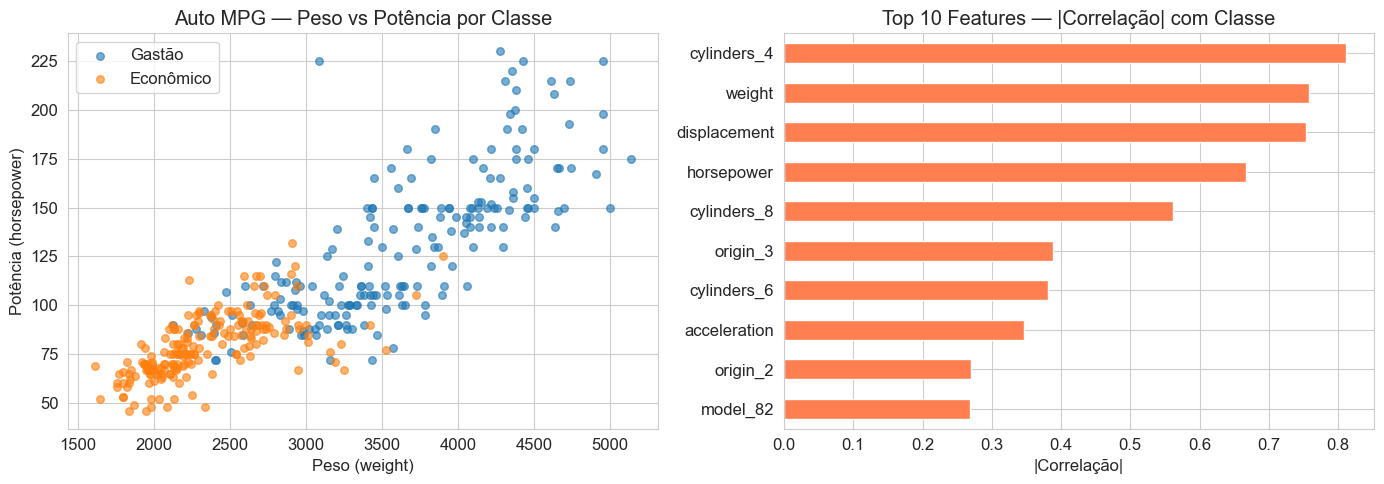

In [7]:
# Visualização da classificação Auto MPG
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: weight vs horsepower colorido por classe
for label, name in enumerate(target_names):
    subset = df_clf[df_clf['classe'] == label]
    axes[0].scatter(subset['weight'], subset['horsepower'],
                    label=name, alpha=0.6, s=30)
axes[0].set_xlabel('Peso (weight)')
axes[0].set_ylabel('Potência (horsepower)')
axes[0].set_title('Auto MPG — Peso vs Potência por Classe')
axes[0].legend()

# Top 10 features por correlação com a classe
corr_clf = df_clf.corr(numeric_only=True)['classe'].drop(['classe', 'mpg']).abs().sort_values(ascending=True).tail(10)
corr_clf.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Features — |Correlação| com Classe')
axes[1].set_xlabel('|Correlação|')

plt.tight_layout()
plt.show()

## 3. Pré-processamento dos Dados e Divisão Treino/Teste

Antes de treinar os modelos, precisamos:

1. **Normalizar as features** com `StandardScaler` — transforma cada feature para ter média 0 e desvio padrão 1:

$$z = \frac{x - \mu}{\sigma}$$

2. **Dividir os dados** em treino (80%) e teste (20%) com `train_test_split`.

In [8]:
RANDOM_STATE = 42  # Garantir a reprodutibilidade dos resultados

# ============================================================
# Auto MPG — Regressão
# ============================================================
X_reg = df_reg.drop('mpg', axis=1)
y_reg = df_reg['mpg']

# Dividir em treino e teste
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# Normalizar as features
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

print("🚗 Auto MPG — Regressão:")
print(f"   Treino: {X_reg_train_scaled.shape[0]} amostras | {X_reg_train_scaled.shape[1]} features")
print(f"   Teste:  {X_reg_test_scaled.shape[0]} amostras")

# ============================================================
# Auto MPG — Classificação (Econômico vs Gastão)
# ============================================================
X_clf = df_clf[clf_feature_names]
y_clf = df_clf['classe']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled = scaler_clf.transform(X_clf_test)

print(f"\n🚗 Auto MPG — Classificação:")
print(f"   Treino: {X_clf_train_scaled.shape[0]} amostras")
print(f"   Teste:  {X_clf_test_scaled.shape[0]} amostras")

🚗 Auto MPG — Regressão:
   Treino: 313 amostras | 22 features
   Teste:  79 amostras

🚗 Auto MPG — Classificação:
   Treino: 313 amostras
   Teste:  79 amostras


## 4. Regressão Linear Simples

A regressão linear simples modela a relação entre **uma feature** ($x$) e a **variável-alvo** ($y$):

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x$$

Onde:
- $\hat{\beta}_0$ é o **intercepto** (valor de $\hat{y}$ quando $x = 0$)
- $\hat{\beta}_1$ é a **inclinação** (variação em $\hat{y}$ para cada unidade de variação em $x$)

Os coeficientes são estimados minimizando a **soma dos quadrados dos resíduos (OLS)**:

$$\min_{\beta_0, \beta_1} \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2$$

Vamos usar a feature com **maior correlação** com a variável-alvo, identificada na exploração dos dados.

Feature selecionada: weight
  REGRESSÃO LINEAR SIMPLES
  Intercepto (β₀): 47.2005
  Inclinação (β₁): -0.0079

  Equação: ŷ = 47.2005 + -0.0079 × weight


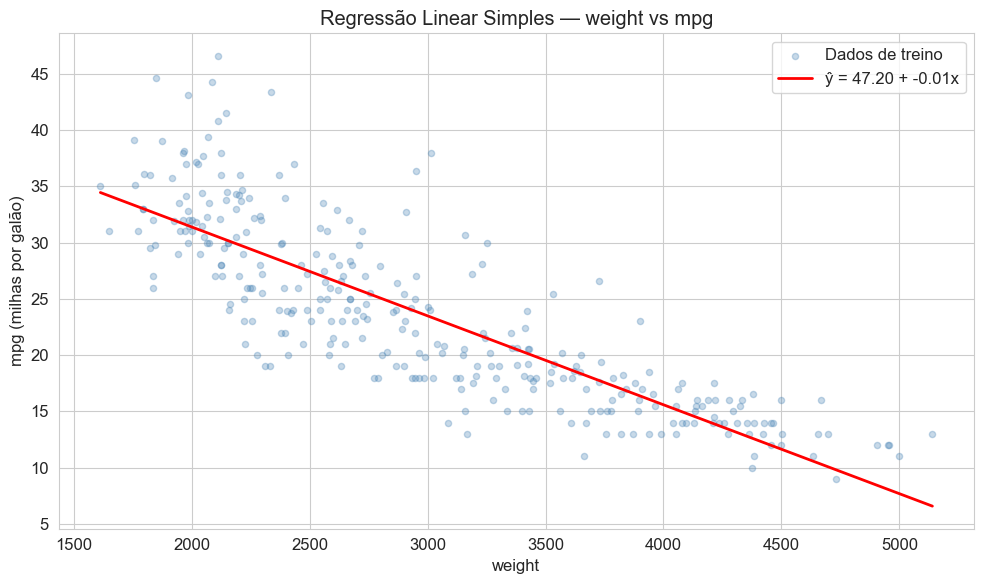


📊 R² no teste: 0.6533
   MSE no teste: 17.6934


In [9]:
# Regressão Linear Simples: usar a feature com maior correlação
best_feature = df_reg.corr(numeric_only=True)['mpg'].drop('mpg').abs().idxmax()
print(f"Feature selecionada: {best_feature}")

X_simple_train = X_reg_train[[best_feature]].values
X_simple_test = X_reg_test[[best_feature]].values

# Treinar o modelo
lr_simple = LinearRegression()
lr_simple.fit(X_simple_train, y_reg_train)

# Coeficientes
beta_0 = lr_simple.intercept_
beta_1 = lr_simple.coef_[0]

print("=" * 50)
print("  REGRESSÃO LINEAR SIMPLES")
print("=" * 50)
print(f"  Intercepto (β₀): {beta_0:.4f}")
print(f"  Inclinação (β₁): {beta_1:.4f}")
print(f"\n  Equação: ŷ = {beta_0:.4f} + {beta_1:.4f} × {best_feature}")
print("=" * 50)

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_simple_train, y_reg_train.values,
           alpha=0.3, s=20, color='steelblue', label='Dados de treino')

# Reta de regressão
x_line = np.linspace(X_simple_train.min(), X_simple_train.max(), 100)
y_line = beta_0 + beta_1 * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label=f'ŷ = {beta_0:.2f} + {beta_1:.2f}x')

ax.set_xlabel(f'{best_feature}')
ax.set_ylabel('mpg (milhas por galão)')
ax.set_title(f'Regressão Linear Simples — {best_feature} vs mpg')
ax.legend()
plt.tight_layout()
plt.show()

# Métricas
y_pred_simple = lr_simple.predict(X_simple_test)
print(f"\n📊 R² no teste: {r2_score(y_reg_test, y_pred_simple):.4f}")
print(f"   MSE no teste: {mean_squared_error(y_reg_test, y_pred_simple):.4f}")

## 5. Regressão Linear Múltipla

Agora usamos **todas as features** (numéricas + one-hot encoded) para prever a variável-alvo (mpg):

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Ou em notação matricial:

$$\hat{y} = X\boldsymbol{\beta}$$

Onde $\boldsymbol{\beta} = (X^T X)^{-1} X^T y$ é a **solução OLS (Ordinary Least Squares)**.

  REGRESSÃO LINEAR MÚLTIPLA — Coeficientes
  Feature                    Coeficiente
----------------------------------------
  weight                         -4.1041
  cylinders_4                     3.5317
  cylinders_8                     3.0569
  model_80                        2.4810
  model_82                        2.0278
  cylinders_6                     1.9674
  model_81                        1.7843
  horsepower                     -1.6004
  model_79                        1.2720
  model_78                        1.0003
  origin_3                        0.9710
  model_77                        0.9093
  displacement                    0.7558
  cylinders_5                     0.6538
  origin_2                        0.6151
  model_76                        0.4897
  model_74                        0.3832
  model_71                        0.2848
  model_75                        0.1798
  model_73                       -0.1729
  acceleration                   -0.0624
  model_72    

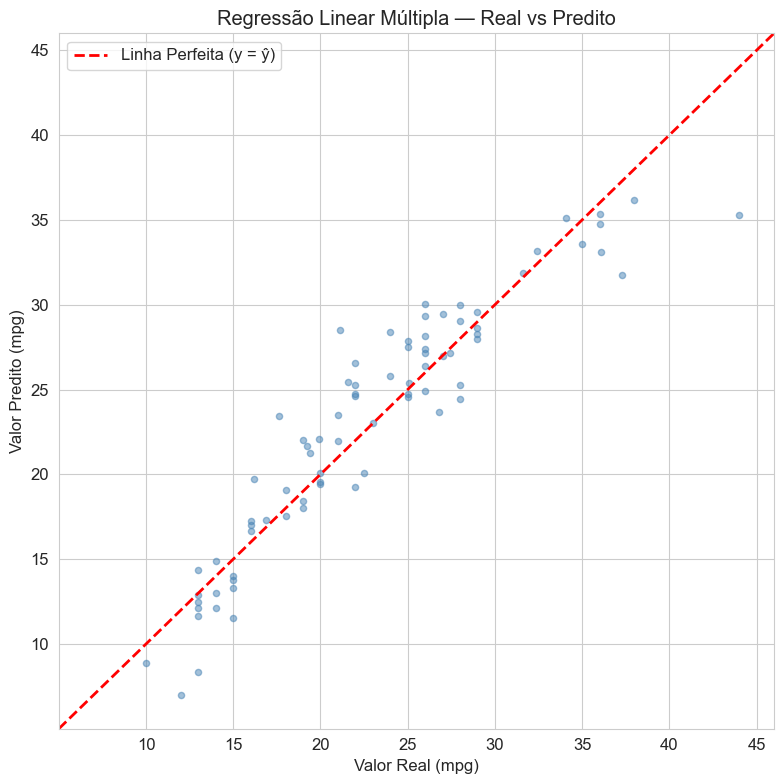

In [10]:
# Regressão Linear Múltipla (todas as features, dados normalizados)
lr_multi = LinearRegression()
lr_multi.fit(X_reg_train_scaled, y_reg_train)
y_pred_multi = lr_multi.predict(X_reg_test_scaled)

# Coeficientes do modelo
print("=" * 60)
print("  REGRESSÃO LINEAR MÚLTIPLA — Coeficientes")
print("=" * 60)
print(f"  {'Feature':<25} {'Coeficiente':>12}")
print("-" * 40)
for feat, coef in sorted(zip(feature_names, lr_multi.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<25} {coef:>12.4f}")
print("-" * 40)
print(f"  {'Intercepto':<25} {lr_multi.intercept_:>12.4f}")
print("=" * 60)

# Gráfico: Predito vs Real
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_reg_test, y_pred_multi, alpha=0.5, s=20, color='steelblue')
lims = [min(y_reg_test.min(), y_pred_multi.min()) - 2,
        max(y_reg_test.max(), y_pred_multi.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=2, label='Linha Perfeita (y = ŷ)')
ax.set_xlabel('Valor Real (mpg)')
ax.set_ylabel('Valor Predito (mpg)')
ax.set_title('Regressão Linear Múltipla — Real vs Predito')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

## 6. Avaliação de Métricas da Regressão

As métricas fundamentais para avaliação de modelos de regressão:

| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **R²** | $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proporção da variância explicada (0 a 1) |
| **MSE** | $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | Erro quadrático médio |
| **RMSE** | $RMSE = \sqrt{MSE}$ | Raiz do MSE (mesma unidade de $y$) |
| **MAE** | $MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$ | Erro absoluto médio |

  MÉTRICAS — Regressão Linear Múltipla
  R² (coef. de determinação): 0.8691
  MSE (erro quadrático médio): 6.6817
  RMSE (raiz do MSE):          2.5849
  MAE (erro absoluto médio):    1.9476


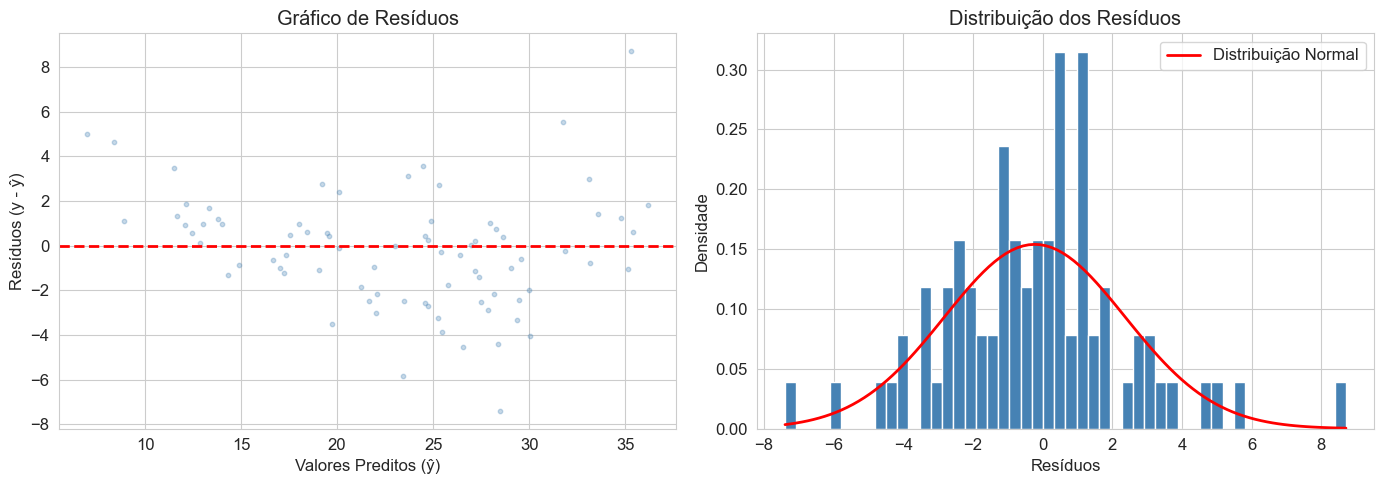

In [11]:
# Métricas da Regressão Linear Múltipla
r2 = r2_score(y_reg_test, y_pred_multi)
mse = mean_squared_error(y_reg_test, y_pred_multi)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_reg_test, y_pred_multi)

print("=" * 50)
print("  MÉTRICAS — Regressão Linear Múltipla")
print("=" * 50)
print(f"  R² (coef. de determinação): {r2:.4f}")
print(f"  MSE (erro quadrático médio): {mse:.4f}")
print(f"  RMSE (raiz do MSE):          {rmse:.4f}")
print(f"  MAE (erro absoluto médio):    {mae:.4f}")
print("=" * 50)

# Gráfico de Resíduos
residuos = y_reg_test - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Valores preditos
axes[0].scatter(y_pred_multi, residuos, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Preditos (ŷ)')
axes[0].set_ylabel('Resíduos (y - ŷ)')
axes[0].set_title('Gráfico de Resíduos')

# Distribuição dos resíduos
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='white', density=True)
axes[1].set_xlabel('Resíduos')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição dos Resíduos')

# Curva normal para referência
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
from scipy.stats import norm
axes[1].plot(x_norm, norm.pdf(x_norm, residuos.mean(), residuos.std()),
             'r-', linewidth=2, label='Distribuição Normal')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Regularização com Ridge Regression ($L_2$)

O Ridge adiciona uma **penalidade $L_2$** (norma quadrática) sobre os coeficientes à função custo:

$$J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

**Efeito:** Os coeficientes são **encolhidos** (shrinkage) em direção a zero, mas **nunca são zerados**. Isso reduz o overfitting ao controlar a magnitude dos coeficientes.

O parâmetro $\alpha$ controla a intensidade da regularização:
- $\alpha = 0$: equivale à regressão linear comum
- $\alpha \to \infty$: todos os coeficientes tendem a zero

  RIDGE REGRESSION (L₂)
  Melhor α: 1.4175
  R²: 0.8687
  MSE: 6.7010
  MAE: 1.9547


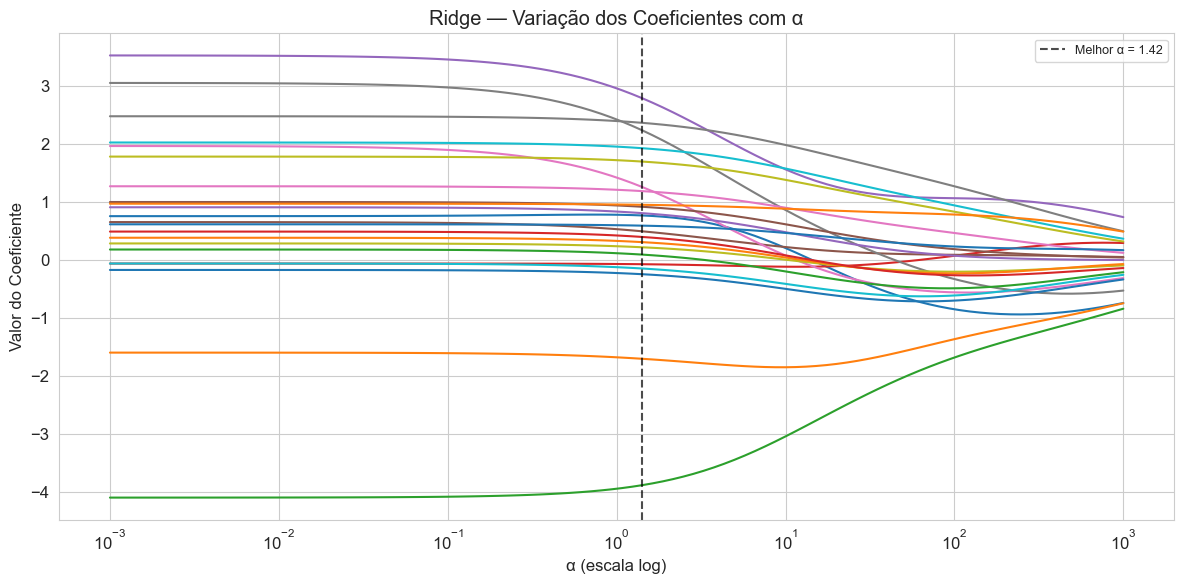

In [12]:
# Ridge Regression com validação cruzada para encontrar o melhor alpha
alphas_ridge = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_cv.fit(X_reg_train_scaled, y_reg_train)
y_pred_ridge = ridge_cv.predict(X_reg_test_scaled)

print("=" * 50)
print("  RIDGE REGRESSION (L₂)")
print("=" * 50)
print(f"  Melhor α: {ridge_cv.alpha_:.4f}")
print(f"  R²: {r2_score(y_reg_test, y_pred_ridge):.4f}")
print(f"  MSE: {mean_squared_error(y_reg_test, y_pred_ridge):.4f}")
print(f"  MAE: {mean_absolute_error(y_reg_test, y_pred_ridge):.4f}")
print("=" * 50)

# Como os coeficientes variam com alpha
fig, ax = plt.subplots(figsize=(12, 6))

coefs_ridge = []
for a in alphas_ridge:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_reg_train_scaled, y_reg_train)
    coefs_ridge.append(ridge_temp.coef_)

coefs_ridge = np.array(coefs_ridge)

for i, feat in enumerate(feature_names):
    ax.plot(alphas_ridge, coefs_ridge[:, i], label=feat if len(feature_names) <= 15 else None)

ax.axvline(x=ridge_cv.alpha_, color='black', linestyle='--', alpha=0.7, label=f'Melhor α = {ridge_cv.alpha_:.2f}')
ax.set_xscale('log')
ax.set_xlabel('α (escala log)')
ax.set_ylabel('Valor do Coeficiente')
ax.set_title('Ridge — Variação dos Coeficientes com α')
if len(feature_names) <= 15:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
else:
    ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Regularização com Lasso Regression ($L_1$)

O Lasso utiliza uma **penalidade $L_1$** (norma absoluta):

$$J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

**Vantagem principal:** O Lasso pode zerar coeficientes completamente, realizando **seleção automática de features**. Isso o torna ideal quando suspeitamos que apenas um subconjunto das features é relevante.

  LASSO REGRESSION (L₁)
  Melhor α: 0.033516
  R²: 0.8635
  MSE: 6.9665
  MAE: 1.9883

📋 Coeficientes do Lasso:
  Feature                    Coeficiente     Status
--------------------------------------------------
  weight                         -3.5277    ✅ Ativa
  model_80                        2.0587    ✅ Ativa
  horsepower                     -1.6475    ✅ Ativa
  model_82                        1.6256    ✅ Ativa
  model_81                        1.4246    ✅ Ativa
  cylinders_4                     1.3440    ✅ Ativa
  cylinders_8                     0.9248    ✅ Ativa
  model_79                        0.9195    ✅ Ativa
  origin_3                        0.7853    ✅ Ativa
  model_78                        0.6290    ✅ Ativa
  model_77                        0.4913    ✅ Ativa
  model_73                       -0.4514    ✅ Ativa
  origin_2                        0.4262    ✅ Ativa
  model_72                       -0.3675    ✅ Ativa
  displacement                    0.2320    ✅ Ativa
  cyl

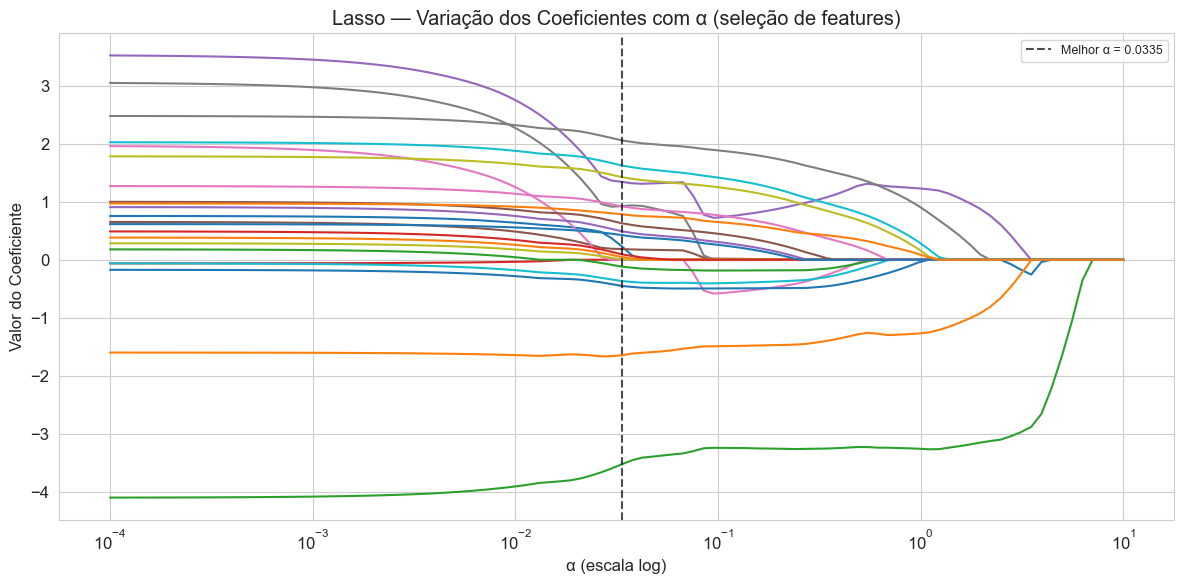

In [13]:
# Lasso Regression com validação cruzada
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_reg_train_scaled, y_reg_train)
y_pred_lasso = lasso_cv.predict(X_reg_test_scaled)

print("=" * 50)
print("  LASSO REGRESSION (L₁)")
print("=" * 50)
print(f"  Melhor α: {lasso_cv.alpha_:.6f}")
print(f"  R²: {r2_score(y_reg_test, y_pred_lasso):.4f}")
print(f"  MSE: {mean_squared_error(y_reg_test, y_pred_lasso):.4f}")
print(f"  MAE: {mean_absolute_error(y_reg_test, y_pred_lasso):.4f}")
print("=" * 50)

# Coeficientes e seleção de features
print("\n📋 Coeficientes do Lasso:")
print(f"  {'Feature':<25} {'Coeficiente':>12} {'Status':>10}")
print("-" * 50)
for feat, coef in sorted(zip(feature_names, lasso_cv.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    status = "✅ Ativa" if abs(coef) > 1e-6 else "❌ Zerada"
    print(f"  {feat:<25} {coef:>12.4f} {status:>10}")

n_zerados = np.sum(np.abs(lasso_cv.coef_) < 1e-6)
n_ativos = len(feature_names) - n_zerados
print(f"\n  Features ativas: {n_ativos}/{len(feature_names)}")
print(f"  Features zeradas pelo Lasso: {n_zerados}/{len(feature_names)}")

# Gráfico da variação dos coeficientes com alpha
fig, ax = plt.subplots(figsize=(12, 6))

alphas_lasso = np.logspace(-4, 1, 100)
coefs_lasso = []
for a in alphas_lasso:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_reg_train_scaled, y_reg_train)
    coefs_lasso.append(lasso_temp.coef_)

coefs_lasso = np.array(coefs_lasso)

for i, feat in enumerate(feature_names):
    ax.plot(alphas_lasso, coefs_lasso[:, i], label=feat if len(feature_names) <= 15 else None)

ax.axvline(x=lasso_cv.alpha_, color='black', linestyle='--', alpha=0.7,
           label=f'Melhor α = {lasso_cv.alpha_:.4f}')
ax.set_xscale('log')
ax.set_xlabel('α (escala log)')
ax.set_ylabel('Valor do Coeficiente')
ax.set_title('Lasso — Variação dos Coeficientes com α (seleção de features)')
if len(feature_names) <= 15:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
else:
    ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Comparação com ElasticNet ($L_1 + L_2$)

O **ElasticNet** combina as penalidades Ridge e Lasso:

$$J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \left( \rho \sum_{j=1}^{p}|\beta_j| + \frac{1-\rho}{2} \sum_{j=1}^{p}\beta_j^2 \right)$$

Onde:
- $\alpha$ controla a intensidade geral da regularização
- $\rho$ (`l1_ratio`) controla a mistura entre $L_1$ e $L_2$:
  - $\rho = 1$: puro Lasso
  - $\rho = 0$: puro Ridge
  - $0 < \rho < 1$: combinação de ambos

In [14]:
# ElasticNet com validação cruzada
enet_cv = ElasticNetCV(
    alphas=np.logspace(-4, 1, 50),
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    cv=5, random_state=RANDOM_STATE, max_iter=10000
)
enet_cv.fit(X_reg_train_scaled, y_reg_train)
y_pred_enet = enet_cv.predict(X_reg_test_scaled)

print("=" * 50)
print("  ELASTICNET (L₁ + L₂)")
print("=" * 50)
print(f"  Melhor α:        {enet_cv.alpha_:.6f}")
print(f"  Melhor l1_ratio: {enet_cv.l1_ratio_:.2f}")
print(f"  R²: {r2_score(y_reg_test, y_pred_enet):.4f}")
print(f"  MSE: {mean_squared_error(y_reg_test, y_pred_enet):.4f}")
print(f"  MAE: {mean_absolute_error(y_reg_test, y_pred_enet):.4f}")
print("=" * 50)

# ============================================================
# Tabela comparativa dos 3 modelos regularizados + Linear
# ============================================================
models_reg = {
    'Linear': (lr_multi, y_pred_multi),
    'Ridge': (ridge_cv, y_pred_ridge),
    'Lasso': (lasso_cv, y_pred_lasso),
    'ElasticNet': (enet_cv, y_pred_enet),
}

resultados = []
for nome, (modelo, y_pred) in models_reg.items():
    resultados.append({
        'Modelo': nome,
        'R²': r2_score(y_reg_test, y_pred),
        'MSE': mean_squared_error(y_reg_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred)),
        'MAE': mean_absolute_error(y_reg_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\n📊 Comparação de Métricas:")
df_resultados.style.format('{:.4f}').highlight_min(axis=0, subset=['MSE', 'RMSE', 'MAE']).highlight_max(axis=0, subset=['R²'])

  ELASTICNET (L₁ + L₂)
  Melhor α:        0.006866
  Melhor l1_ratio: 0.50
  R²: 0.8687
  MSE: 6.7010
  MAE: 1.9561

📊 Comparação de Métricas:


,R²,MSE,RMSE,MAE
Modelo,,,,
Linear,0.8691,6.6817,2.5849,1.9476
Ridge,0.8687,6.7010,2.5886,1.9547
Lasso,0.8635,6.9665,2.6394,1.9883
ElasticNet,0.8687,6.7010,2.5886,1.9561


## 10. Seleção de Variáveis

A **seleção de variáveis** (feature selection) é fundamental para construir modelos **robustos e eficientes**. Com o One-Hot Encoding do Auto MPG, temos diversas features — muitas das quais podem ser pouco relevantes. A seleção ajuda a reduzir a dimensionalidade e melhorar a interpretabilidade.

### Técnicas abordadas:

| Técnica | Estratégia | Como funciona |
|---------|-----------|---------------|
| **Lasso** (embutida) | Regularização $L_1$ | Zera coeficientes de features irrelevantes |
| **RFE** (wrapper) | Eliminação Recursiva | Remove features menos importantes iterativamente |
| **SelectFromModel** (embutida) | Baseada em importância | Seleciona features com coeficientes acima de um limiar |

> 💡 **Nota:** A seleção de variáveis reduz a dimensionalidade, melhora a interpretabilidade e pode aumentar a generalização do modelo.

In [15]:
# ============================================================
# 10.1 Seleção via Lasso (já treinado)
# ============================================================
print("=" * 60)
print("  SELEÇÃO DE VARIÁVEIS")
print("=" * 60)

# Features selecionadas pelo Lasso
print("\n📌 10.1 — Seleção via Lasso (coeficientes ≠ 0):")
lasso_features = pd.DataFrame({
    'Feature': feature_names,
    'Coef. Lasso': lasso_cv.coef_,
    'Selecionada': np.abs(lasso_cv.coef_) > 1e-6
})
lasso_features['|Coef.|'] = np.abs(lasso_features['Coef. Lasso'])
lasso_features = lasso_features.sort_values('|Coef.|', ascending=False)
print(lasso_features[['Feature', 'Coef. Lasso', 'Selecionada']].to_string(index=False))

# ============================================================
# 10.2 RFE — Recursive Feature Elimination
# ============================================================
n_select = max(4, len(feature_names) // 3)  # selecionar ~1/3 das features
print(f"\n📌 10.2 — RFE (Recursive Feature Elimination, selecionando {n_select} features):")
rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_select, step=1)
rfe.fit(X_reg_train_scaled, y_reg_train)

rfe_results = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe.ranking_,
    'Selecionada': rfe.support_,
}).sort_values('Ranking')
print(rfe_results.to_string(index=False))

# Score com features selecionadas por RFE
y_pred_rfe = rfe.predict(X_reg_test_scaled)
print(f"\n  R² com RFE ({n_select} features): {r2_score(y_reg_test, y_pred_rfe):.4f}")
print(f"  R² com todas features:   {r2_score(y_reg_test, y_pred_multi):.4f}")

# ============================================================
# 10.3 SelectFromModel (com Lasso como estimador)
# ============================================================
print("\n📌 10.3 — SelectFromModel (baseado no Lasso):")
sfm = SelectFromModel(lasso_cv, prefit=True)
X_reg_train_sfm = sfm.transform(X_reg_train_scaled)
X_reg_test_sfm = sfm.transform(X_reg_test_scaled)

selected_mask = sfm.get_support()
selected_features = [f for f, s in zip(feature_names, selected_mask) if s]
print(f"  Features selecionadas ({len(selected_features)}): {selected_features}")

lr_sfm = LinearRegression().fit(X_reg_train_sfm, y_reg_train)
y_pred_sfm = lr_sfm.predict(X_reg_test_sfm)
print(f"  R² com SelectFromModel: {r2_score(y_reg_test, y_pred_sfm):.4f}")

  SELEÇÃO DE VARIÁVEIS

📌 10.1 — Seleção via Lasso (coeficientes ≠ 0):
     Feature  Coef. Lasso  Selecionada
      weight    -3.527720         True
    model_80     2.058734         True
  horsepower    -1.647475         True
    model_82     1.625574         True
    model_81     1.424624         True
 cylinders_4     1.344031         True
 cylinders_8     0.924806         True
    model_79     0.919452         True
    origin_3     0.785284         True
    model_78     0.628966         True
    model_77     0.491265         True
    model_73    -0.451414         True
    origin_2     0.426230         True
    model_72    -0.367461         True
displacement     0.232037         True
 cylinders_5     0.184137         True
    model_75    -0.119175         True
    model_76     0.094043         True
    model_74     0.047044         True
    model_71     0.002726         True
 cylinders_6     0.000000        False
acceleration    -0.000000        False

📌 10.2 — RFE (Recursive Feature

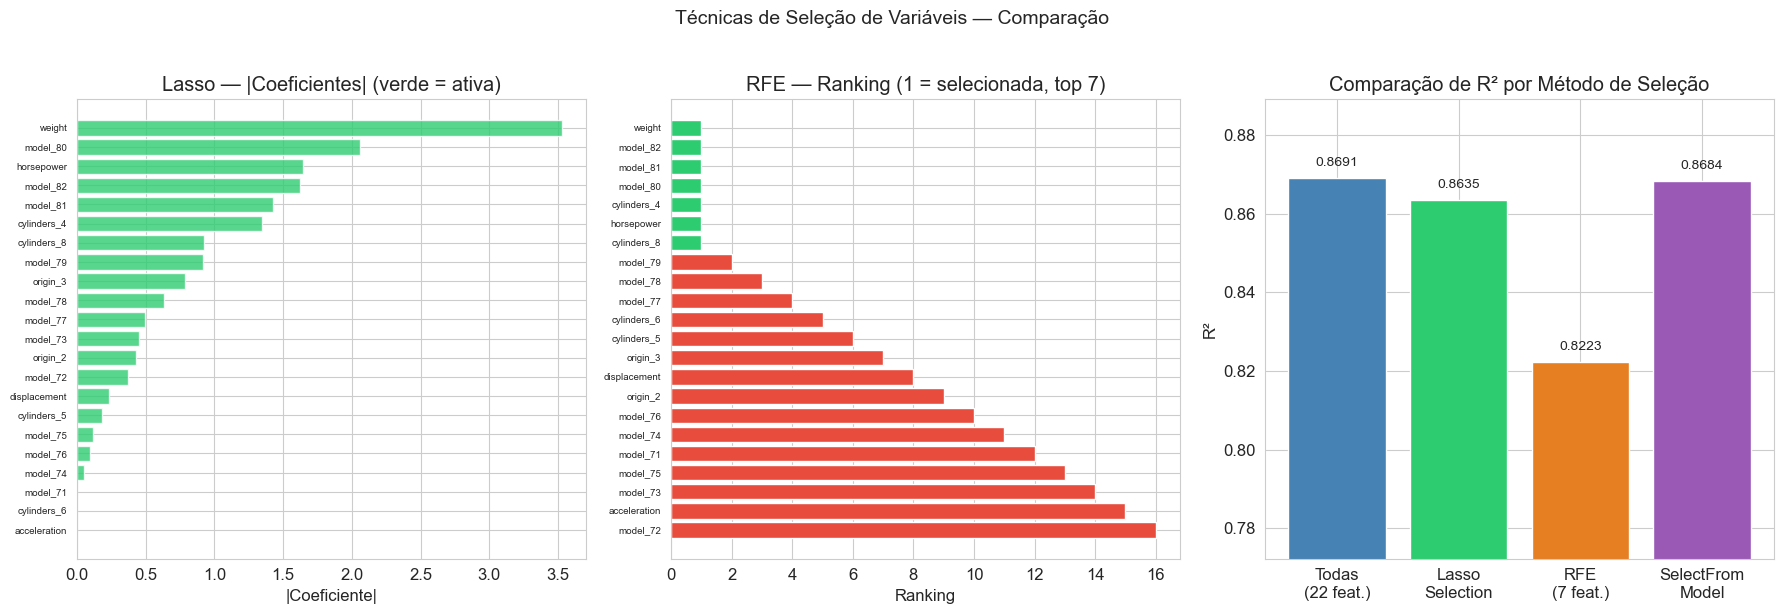

In [16]:
# Visualização comparativa das técnicas de seleção
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Lasso — |Coeficientes|
lasso_sorted = pd.DataFrame({
    'Feature': feature_names,
    'Lasso': np.abs(lasso_cv.coef_),
}).sort_values('Lasso', ascending=True)

colors_lasso = ['#2ecc71' if v > 1e-6 else '#e74c3c' for v in lasso_sorted['Lasso'].values]
axes[0].barh(lasso_sorted['Feature'].values, lasso_sorted['Lasso'].values,
             color=colors_lasso, alpha=0.8)
axes[0].set_title('Lasso — |Coeficientes| (verde = ativa)')
axes[0].set_xlabel('|Coeficiente|')
axes[0].tick_params(axis='y', labelsize=7)

# RFE ranking
rfe_sorted = pd.DataFrame({'Feature': feature_names, 'Ranking': rfe.ranking_}).sort_values('Ranking', ascending=False)
colors_rfe = ['#2ecc71' if r == 1 else '#e74c3c' for r in rfe_sorted['Ranking']]
axes[1].barh(rfe_sorted['Feature'].values, rfe_sorted['Ranking'].values, color=colors_rfe)
axes[1].set_title(f'RFE — Ranking (1 = selecionada, top {n_select})')
axes[1].set_xlabel('Ranking')
axes[1].tick_params(axis='y', labelsize=7)

# Resumo comparativo
n_total = len(feature_names)
methods = [f'Todas\n({n_total} feat.)', 'Lasso\nSelection', f'RFE\n({n_select} feat.)', 'SelectFrom\nModel']
r2_scores = [
    r2_score(y_reg_test, y_pred_multi),
    r2_score(y_reg_test, y_pred_lasso),
    r2_score(y_reg_test, y_pred_rfe),
    r2_score(y_reg_test, y_pred_sfm),
]
bars = axes[2].bar(methods, r2_scores, color=['steelblue', '#2ecc71', '#e67e22', '#9b59b6'])
axes[2].set_ylabel('R²')
axes[2].set_title('Comparação de R² por Método de Seleção')
axes[2].set_ylim(min(r2_scores) - 0.05, max(r2_scores) + 0.02)
for bar, score in zip(bars, r2_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{score:.4f}', ha='center', fontsize=10)

plt.suptitle('Técnicas de Seleção de Variáveis — Comparação', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Regressão Logística para Classificação (Auto MPG)

A **Regressão Logística** é um modelo linear para **classificação**. Apesar do nome, não é usada para regressão!

### Caso binário (Auto MPG — Econômico vs Gastão)
A probabilidade da classe positiva é modelada pela **função sigmoide**:

$$P(y=1|x) = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

A função custo é a **entropia cruzada binária** (binary cross-entropy):

$$J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

> 💡 Usamos o mesmo dataset Auto MPG, mas agora como problema de **classificação binária**: carros com mpg ≥ mediana são **Econômicos**, os demais são **Gastões**. Vamos usar a penalidade $L_2$ (padrão).

  REGRESSÃO LOGÍSTICA — Auto MPG (Econômico vs Gastão)
  Acurácia no teste: 0.8734
  Nº de classes: 2
  Nº de features: 22
  Estratégia: binária (sigmoide)

📋 Top 10 Coeficientes (maior impacto):
     Feature  Coeficiente
      weight    -1.976677
  horsepower    -1.464868
 cylinders_4     1.102688
    model_81     1.052248
    model_79     0.801390
    model_73    -0.745313
displacement    -0.708979
    model_72    -0.604608
 cylinders_8     0.587765
    model_80     0.546561

Intercepto: -0.5657


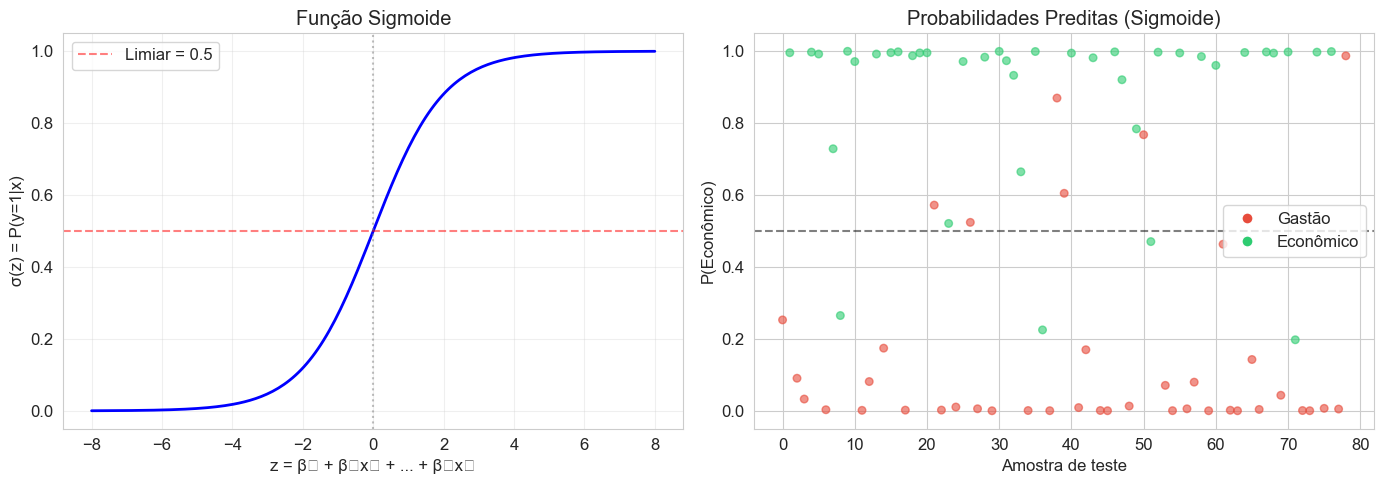

In [17]:
# Treinar Regressão Logística (L2 — padrão)
log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg.fit(X_clf_train_scaled, y_clf_train)

# Predições
y_clf_pred = log_reg.predict(X_clf_test_scaled)
y_clf_proba = log_reg.predict_proba(X_clf_test_scaled)

print("=" * 60)
print("  REGRESSÃO LOGÍSTICA — Auto MPG (Econômico vs Gastão)")
print("=" * 60)
print(f"  Acurácia no teste: {accuracy_score(y_clf_test, y_clf_pred):.4f}")
print(f"  Nº de classes: {len(target_names)}")
print(f"  Nº de features: {len(clf_feature_names)}")
print(f"  Estratégia: binária (sigmoide)")
print("=" * 60)

# Top 10 coeficientes (maiores em valor absoluto)
coef_importance = pd.DataFrame({
    'Feature': clf_feature_names,
    'Coeficiente': log_reg.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\n📋 Top 10 Coeficientes (maior impacto):")
print(coef_importance.head(10).to_string(index=False))
print(f"\nIntercepto: {log_reg.intercept_[0]:.4f}")

# Visualização da função sigmoide
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoide
z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))
axes[0].plot(z, sigma, 'b-', linewidth=2)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Limiar = 0.5')
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('z = β₀ + β₁x₁ + ... + βₚxₚ')
axes[0].set_ylabel('σ(z) = P(y=1|x)')
axes[0].set_title('Função Sigmoide')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Probabilidades preditas — coloridas pela classe real
colors = ['#e74c3c' if y == 0 else '#2ecc71' for y in y_clf_test]
axes[1].scatter(range(len(y_clf_test)), y_clf_proba[:, 1],
                c=colors, alpha=0.6, s=30)
axes[1].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Limiar 0.5')
axes[1].set_xlabel('Amostra de teste')
axes[1].set_ylabel('P(Econômico)')
axes[1].set_title('Probabilidades Preditas (Sigmoide)')
# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Gastão'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=8, label='Econômico'),
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 12. Avaliação do Modelo de Classificação

### Métricas de classificação:

| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **Acurácia** | $\frac{VP + VN}{Total}$ | Proporção de acertos gerais |
| **Precisão** | $\frac{VP}{VP + FP}$ | Dos classificados como positivos, quantos realmente são |
| **Recall** | $\frac{VP}{VP + FN}$ | Dos positivos reais, quantos foram detectados |
| **F1-Score** | $2 \cdot \frac{Precisão \cdot Recall}{Precisão + Recall}$ | Média harmônica entre precisão e recall |

  AVALIAÇÃO — Regressão Logística (Auto MPG)
              precision    recall  f1-score   support

      Gastão       0.89      0.85      0.87        40
   Econômico       0.85      0.90      0.88        39

    accuracy                           0.87        79
   macro avg       0.87      0.87      0.87        79
weighted avg       0.87      0.87      0.87        79



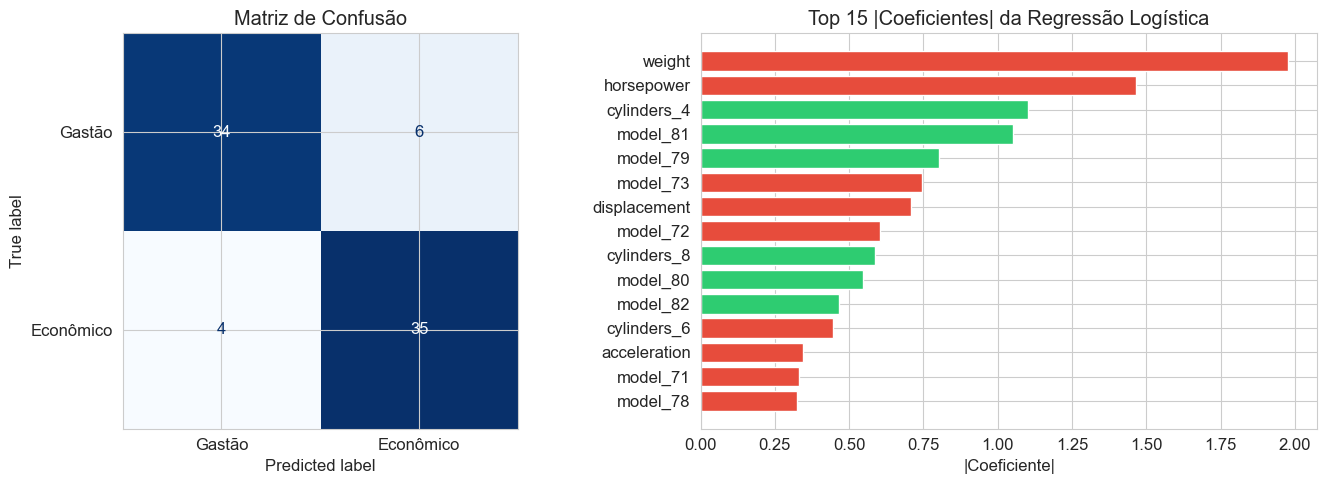

In [18]:
# Relatório de classificação
print("=" * 60)
print("  AVALIAÇÃO — Regressão Logística (Auto MPG)")
print("=" * 60)
print(classification_report(y_clf_test, y_clf_pred, target_names=target_names))

# Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap da matriz de confusão
cm = confusion_matrix(y_clf_test, y_clf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão')

# Top 15 features por |coeficiente|
coef_top = coef_importance.head(15).sort_values('Coeficiente', key=abs)
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_top['Coeficiente']]
axes[1].barh(coef_top['Feature'], coef_top['Coeficiente'].abs(), color=colors_bar)
axes[1].set_title('Top 15 |Coeficientes| da Regressão Logística')
axes[1].set_xlabel('|Coeficiente|')

plt.tight_layout()
plt.show()

## 13. Regressão Linear com TensorFlow/Keras

Conforme a ementa, vamos implementar o **mesmo problema de regressão** usando **TensorFlow/Keras**. Isso demonstra que um modelo linear é equivalente a uma rede neural com:
- **1 camada Dense** com 1 neurônio
- **Sem função de ativação** (linear)
- **Função custo MSE** e otimizador **SGD** ou **Adam**

Modelo equivalente:

$$\hat{y} = W \cdot X + b$$

Onde $W$ são os pesos (equivalentes a $\boldsymbol{\beta}$) e $b$ é o bias (equivalente a $\beta_0$).

In [19]:
# ============================================================
# Regressão Linear com TensorFlow/Keras
# ============================================================

# Construir o modelo — equivalente a LinearRegression()
tf.random.set_seed(RANDOM_STATE)

modelo_tf = keras.Sequential([
    layers.Dense(1, input_shape=(X_reg_train_scaled.shape[1],), activation='linear',
                 name='camada_linear')
])

modelo_tf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

modelo_tf.summary()

# Treinar o modelo
print("\n🚀 Treinando o modelo TensorFlow...")
history = modelo_tf.fit(
    X_reg_train_scaled, y_reg_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    ],
    verbose=0
)

print("✅ Treinamento concluído!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_linear (Dense)           │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (92.00 B)

 Trainable params: 23 (92.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Treinando o modelo TensorFlow...
✅ Treinamento concluído!


  COMPARAÇÃO: scikit-learn vs TensorFlow/Keras
  Métrica      scikit-learn     TensorFlow
------------------------------------------
  R²                 0.8691        -7.1284
  MSE                6.6817       414.8788
  MAE                1.9476        20.0099

📋 Coeficientes: scikit-learn vs TensorFlow:
  Feature                      sklearn   TensorFlow
--------------------------------------------------
  displacement                  0.7558      -0.8213
  horsepower                   -1.6004      -0.8868
  weight                       -4.1041      -0.6305
  acceleration                 -0.0624      -0.0101
  cylinders_4                   3.5317       1.0667
  cylinders_5                   0.6538       0.5895
  cylinders_6                   1.9674      -0.4501
  cylinders_8                   3.0569      -0.8713
  model_71                      0.2848      -1.7739
  model_72                     -0.0619      -0.7606
  model_73                     -0.1729      -1.4410
  model_74        

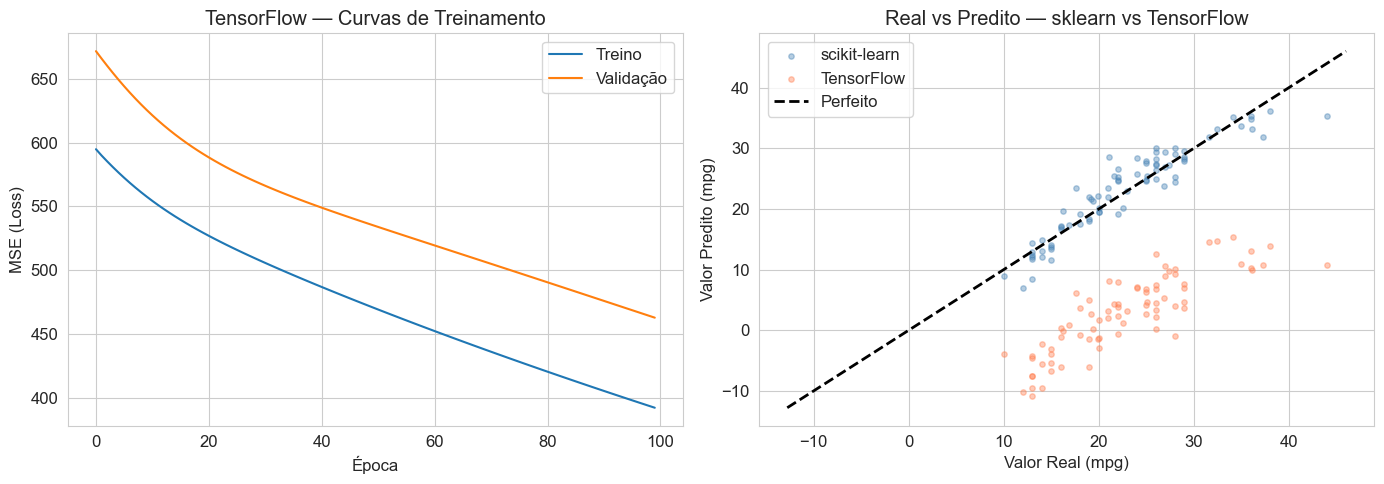


💡 Nota: ambos convergem para a mesma solução, pois são o mesmo modelo linear!
   A diferença está no método de otimização: OLS (sklearn) vs SGD/Adam (TensorFlow).


In [20]:
# Avaliar e comparar com scikit-learn
y_pred_tf = modelo_tf.predict(X_reg_test_scaled, verbose=0).flatten()

r2_tf = r2_score(y_reg_test, y_pred_tf)
mse_tf = mean_squared_error(y_reg_test, y_pred_tf)
mae_tf = mean_absolute_error(y_reg_test, y_pred_tf)

print("=" * 60)
print("  COMPARAÇÃO: scikit-learn vs TensorFlow/Keras")
print("=" * 60)
print(f"  {'Métrica':<10} {'scikit-learn':>14} {'TensorFlow':>14}")
print("-" * 42)
print(f"  {'R²':<10} {r2_score(y_reg_test, y_pred_multi):>14.4f} {r2_tf:>14.4f}")
print(f"  {'MSE':<10} {mean_squared_error(y_reg_test, y_pred_multi):>14.4f} {mse_tf:>14.4f}")
print(f"  {'MAE':<10} {mean_absolute_error(y_reg_test, y_pred_multi):>14.4f} {mae_tf:>14.4f}")
print("=" * 60)

# Comparar coeficientes
pesos_tf = modelo_tf.get_layer('camada_linear').get_weights()
w_tf = pesos_tf[0].flatten()
b_tf = pesos_tf[1][0]

print("\n📋 Coeficientes: scikit-learn vs TensorFlow:")
print(f"  {'Feature':<25} {'sklearn':>10} {'TensorFlow':>12}")
print("-" * 50)
for feat, c_sk, c_tf in zip(feature_names, lr_multi.coef_, w_tf):
    print(f"  {feat:<25} {c_sk:>10.4f} {c_tf:>12.4f}")
print("-" * 50)
print(f"  {'Intercept':<25} {lr_multi.intercept_:>10.4f} {b_tf:>12.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de treinamento
axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE (Loss)')
axes[0].set_title('TensorFlow — Curvas de Treinamento')
axes[0].legend()

# Predito vs Real — comparação lado a lado
axes[1].scatter(y_reg_test, y_pred_multi, alpha=0.4, s=15, color='steelblue', label='scikit-learn')
axes[1].scatter(y_reg_test, y_pred_tf, alpha=0.4, s=15, color='coral', label='TensorFlow')
lims = [min(y_reg_test.min(), y_pred_multi.min(), y_pred_tf.min()) - 2,
        max(y_reg_test.max(), y_pred_multi.max(), y_pred_tf.max()) + 2]
axes[1].plot(lims, lims, 'k--', linewidth=2, label='Perfeito')
axes[1].set_xlabel('Valor Real (mpg)')
axes[1].set_ylabel('Valor Predito (mpg)')
axes[1].set_title('Real vs Predito — sklearn vs TensorFlow')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 Nota: ambos convergem para a mesma solução, pois são o mesmo modelo linear!")
print("   A diferença está no método de otimização: OLS (sklearn) vs SGD/Adam (TensorFlow).")

## 14. Visualização Comparativa dos Coeficientes

Vamos comparar visualmente os coeficientes de **todos os modelos de regressão** treinados. Isso permite entender o efeito da regularização na magnitude dos coeficientes.

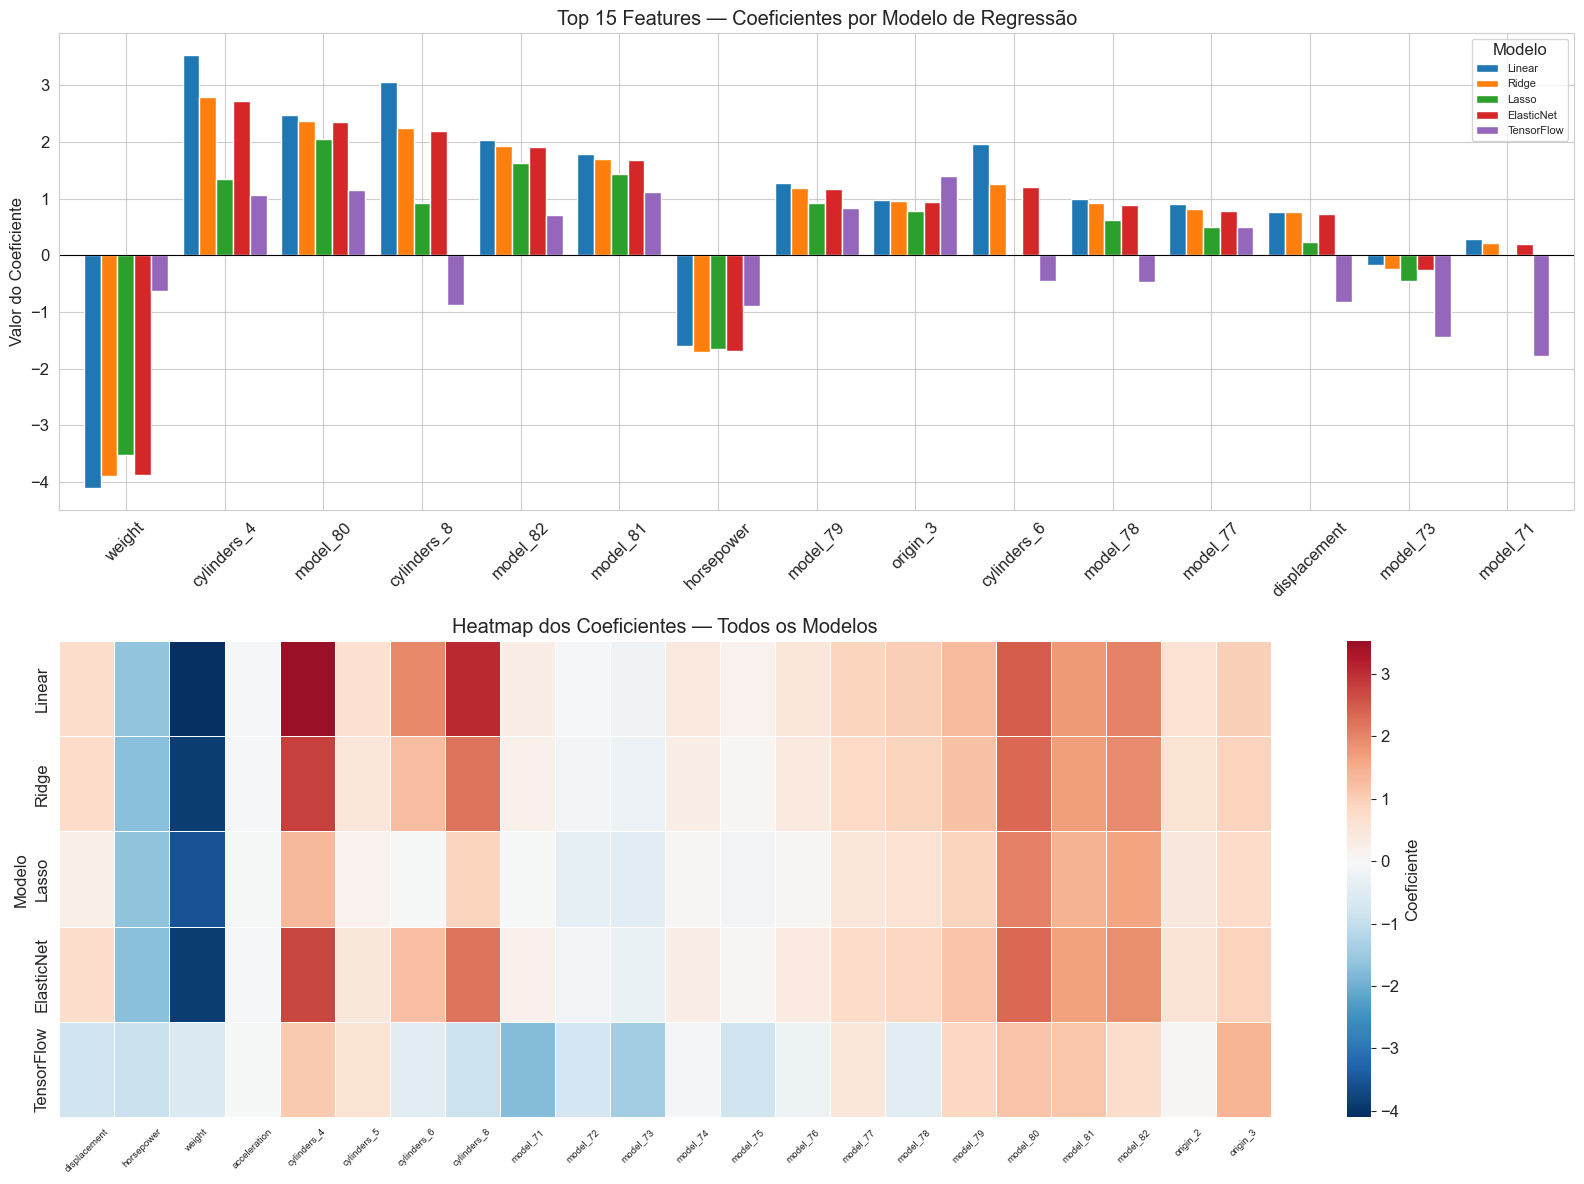


🔍 Interpretação:
  • Linear e TensorFlow produzem coeficientes muito semelhantes (mesmo modelo)
  • Ridge encolhe os coeficientes uniformemente (shrinkage)
  • Lasso ZERA os coeficientes das features menos relevantes (seleção de variáveis!)
  • ElasticNet é um meio-termo entre Ridge e Lasso
  • As features categóricas (one-hot) do Auto MPG permitem visualizar claramente
    quais níveis de cylinders, model e origin são mais relevantes para o consumo


In [21]:
# Comparação dos coeficientes de todos os modelos de regressão
coefs_compare = pd.DataFrame({
    'Linear': lr_multi.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_,
    'ElasticNet': enet_cv.coef_,
    'TensorFlow': w_tf,
}, index=feature_names)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Gráfico de barras agrupadas — top 15 por magnitude média
mean_abs = coefs_compare.abs().mean(axis=1).sort_values(ascending=False)
top_features = mean_abs.head(15).index
coefs_top = coefs_compare.loc[top_features]

coefs_top.plot(kind='bar', ax=axes[0], rot=45, width=0.85)
axes[0].set_title('Top 15 Features — Coeficientes por Modelo de Regressão')
axes[0].set_ylabel('Valor do Coeficiente')
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].legend(title='Modelo', fontsize=8)

# Heatmap
sns.heatmap(coefs_compare.T, annot=len(feature_names) <= 15,
            fmt='.1f' if len(feature_names) <= 15 else '',
            cmap='RdBu_r', center=0,
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Coeficiente'},
            annot_kws={'size': 7})
axes[1].set_title('Heatmap dos Coeficientes — Todos os Modelos')
axes[1].set_ylabel('Modelo')
axes[1].tick_params(axis='x', labelsize=7, rotation=45)

plt.tight_layout()
plt.show()

print("\n🔍 Interpretação:")
print("  • Linear e TensorFlow produzem coeficientes muito semelhantes (mesmo modelo)")
print("  • Ridge encolhe os coeficientes uniformemente (shrinkage)")
print("  • Lasso ZERA os coeficientes das features menos relevantes (seleção de variáveis!)")
print("  • ElasticNet é um meio-termo entre Ridge e Lasso")
print("  • As features categóricas (one-hot) do Auto MPG permitem visualizar claramente")
print("    quais níveis de cylinders, model e origin são mais relevantes para o consumo")

## 15. Comparação Final de Desempenho com Validação Cruzada

Para uma avaliação mais **robusta**, vamos usar **validação cruzada com 5 folds** (`cross_val_score`). Isso evita que a comparação dependa de uma única divisão treino/teste.

$$CV_{score} = \frac{1}{K}\sum_{k=1}^{K} Score_k$$

  VALIDAÇÃO CRUZADA (5 folds) — Modelos de Regressão
  Modelo            R² médio   ± Desvio     R² min     R² max
----------------------------------------------------------
  Linear              0.8379     0.0254     0.8081     0.8749
  Ridge               0.8386     0.0254     0.8110     0.8789
  Lasso               0.8394     0.0236     0.8080     0.8793
  ElasticNet          0.8387     0.0251     0.8116     0.8787


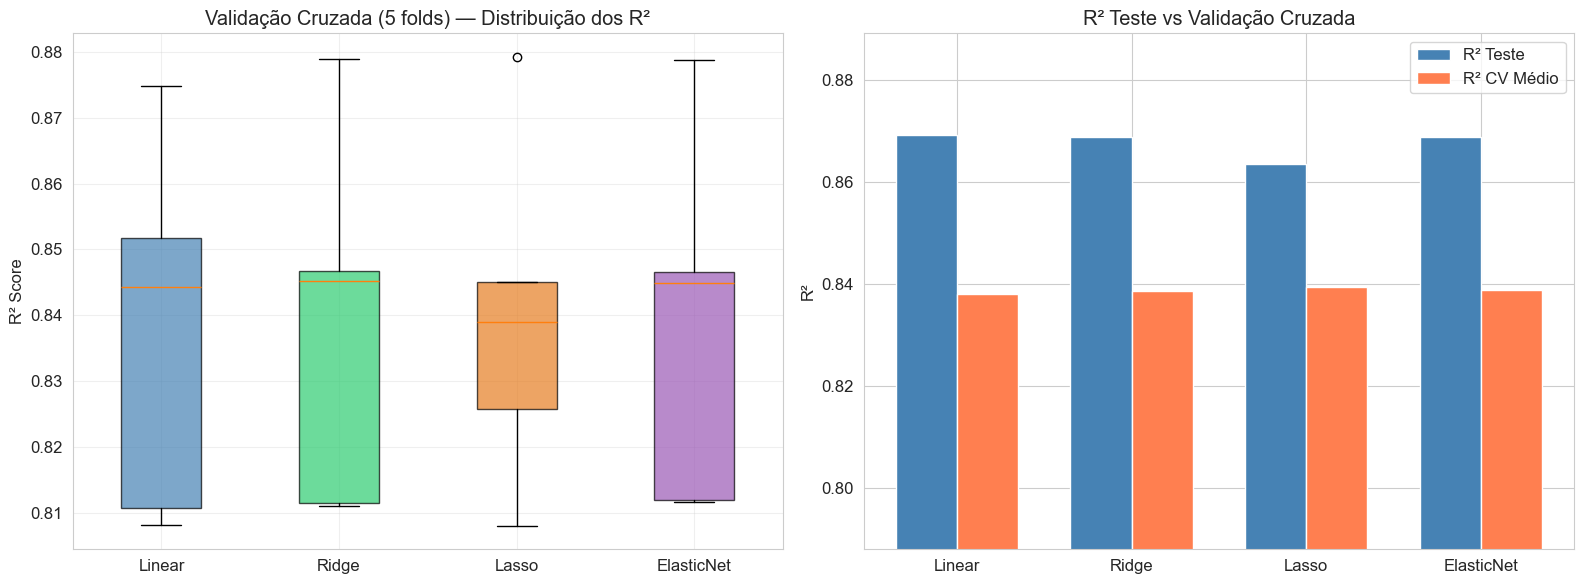


📊 Tabela Consolidada:


,R² (teste),R² CV (média),MSE (teste),MAE (teste)
Modelo,,,,
Linear,0.8691,0.8379,6.6817,1.9476
Ridge,0.8687,0.8386,6.7010,1.9547
Lasso,0.8635,0.8394,6.9665,1.9883
ElasticNet,0.8687,0.8387,6.7010,1.9561


In [22]:
# Validação Cruzada com 5 folds para todos os modelos de regressão
modelos_cv = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=ridge_cv.alpha_),
    'Lasso': Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000),
}

cv_results = {}
print("=" * 60)
print("  VALIDAÇÃO CRUZADA (5 folds) — Modelos de Regressão")
print("=" * 60)
print(f"  {'Modelo':<15} {'R² médio':>10} {'± Desvio':>10} {'R² min':>10} {'R² max':>10}")
print("-" * 58)

for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_reg_train_scaled, y_reg_train,
                             cv=5, scoring='r2')
    cv_results[nome] = scores
    print(f"  {nome:<15} {scores.mean():>10.4f} {scores.std():>10.4f} "
          f"{scores.min():>10.4f} {scores.max():>10.4f}")

print("=" * 60)

# Boxplot dos scores de validação cruzada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
bp_data = [cv_results[m] for m in cv_results]
bp = axes[0].boxplot(bp_data, labels=cv_results.keys(), patch_artist=True)
colors_bp = ['steelblue', '#2ecc71', '#e67e22', '#9b59b6']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Validação Cruzada (5 folds) — Distribuição dos R²')
axes[0].grid(True, alpha=0.3)

# Tabela consolidada no conjunto de teste
df_final = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso', 'ElasticNet'],
    'R² (teste)': [r2_score(y_reg_test, y_pred_multi),
                   r2_score(y_reg_test, y_pred_ridge),
                   r2_score(y_reg_test, y_pred_lasso),
                   r2_score(y_reg_test, y_pred_enet)],
    'R² CV (média)': [cv_results[m].mean() for m in ['Linear', 'Ridge', 'Lasso', 'ElasticNet']],
    'MSE (teste)': [mean_squared_error(y_reg_test, p) for p in
                    [y_pred_multi, y_pred_ridge, y_pred_lasso, y_pred_enet]],
    'MAE (teste)': [mean_absolute_error(y_reg_test, p) for p in
                    [y_pred_multi, y_pred_ridge, y_pred_lasso, y_pred_enet]],
})

# Gráfico de barras agrupadas
x_pos = np.arange(len(df_final))
width = 0.35
axes[1].bar(x_pos - width/2, df_final['R² (teste)'], width, label='R² Teste', color='steelblue')
axes[1].bar(x_pos + width/2, df_final['R² CV (média)'], width, label='R² CV Médio', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_final['Modelo'])
axes[1].set_ylabel('R²')
axes[1].set_title('R² Teste vs Validação Cruzada')
axes[1].legend()
axes[1].set_ylim(df_final[['R² (teste)', 'R² CV (média)']].min().min() - 0.05, 
                 df_final[['R² (teste)', 'R² CV (média)']].max().max() + 0.02)

plt.tight_layout()
plt.show()

print("\n📊 Tabela Consolidada:")
df_final.set_index('Modelo').style.format('{:.4f}').highlight_max(
    axis=0, subset=['R² (teste)', 'R² CV (média)']
).highlight_min(axis=0, subset=['MSE (teste)', 'MAE (teste)'])

## 📝 Conclusão

Nesta aula cobrimos todos os pontos da ementa:

### ✅ Construção e Interpretação de Modelos Lineares
- **Regressão Linear Simples**: relação entre uma variável e o alvo — $\hat{y} = \beta_0 + \beta_1 x$
- **Regressão Linear Múltipla**: extensão para $p$ variáveis — $\hat{y} = X\boldsymbol{\beta}$
- **Regressão Logística**: classificação binária via sigmoide — $P(y=1|x) = \frac{1}{1 + e^{-z}}$
- Interpretação dos coeficientes em todos os modelos
- Utilização de um **único dataset real** (Auto MPG) para regressão e classificação

### ✅ Aplicação com scikit-learn e TensorFlow
- **scikit-learn**: utilizado em todos os modelos (Linear, Ridge, Lasso, ElasticNet, Logística)
- **TensorFlow/Keras**: implementação equivalente da regressão linear como rede neural de 1 camada
- Demonstramos que ambas as bibliotecas convergem para a mesma solução

### ✅ Técnicas de Regularização
| Técnica | Penalidade | Efeito Principal |
|---------|-----------|------------------|
| **Ridge** | $\alpha\sum\beta_j^2$ | Shrinkage (encolhe coeficientes) |
| **Lasso** | $\alpha\sum|\beta_j|$ | Sparsity (zera coeficientes das features menos relevantes) |
| **ElasticNet** | $\alpha(\rho L_1 + (1-\rho)L_2)$ | Combina ambos os efeitos |

### ✅ Seleção de Variáveis
- **Lasso** como método embutido de seleção (coeficientes zerados = features eliminadas)
- **RFE** (Recursive Feature Elimination) como método wrapper
- **SelectFromModel** para seleção baseada em importância dos coeficientes

### 🔑 Pontos-chave para lembrar
1. **Regularização** previne overfitting ao penalizar coeficientes grandes
2. **Seleção de variáveis** melhora a interpretabilidade e pode melhorar a generalização
3. **Validação cruzada** é essencial para uma avaliação robusta dos modelos
4. Modelos lineares são a **base** de muitos algoritmos mais complexos em ML
5. O **pré-processamento** (One-Hot Encoding + StandardScaler) é essencial quando temos variáveis categóricas
6. Um mesmo dataset pode ser usado para **regressão** (prever mpg) e **classificação** (Econômico vs Gastão)
7. O dataset **Auto MPG** demonstra um R² ≈ 0.87 na regressão, mostrando que modelos lineares podem ser bastante eficazes em dados reais